SPRINT 1: DATA FOUNDATION

 Dataset structure defined!
Columns: ['Intern_ID', 'Task_Completion', 'Consistency', 'Engagement', 'Performance']

✅ Raw dataset created! Saved as 'intern_data_raw.csv'

📊 Dataset shape: (10, 5)

First 5 rows:
  Intern_ID  Task_Completion  Consistency  Engagement  Performance
0    INT001               76           72          75           74
1    INT002               82           72          84           79
2    INT003               89           85          86           86
3    INT004               87           86          94           89
4    INT005               73           78          92           81

DATA CLEANING PROCESS

 Checking for missing values...
Intern_ID          0
Task_Completion    0
Consistency        0
Engagement         0
Performance        0
dtype: int64
 No missing values found!

 Checking for duplicate rows...
Duplicate rows found: 0
 No duplicates found!

 Checking data types...
Intern_ID            str
Task_Completion    int64
Consist

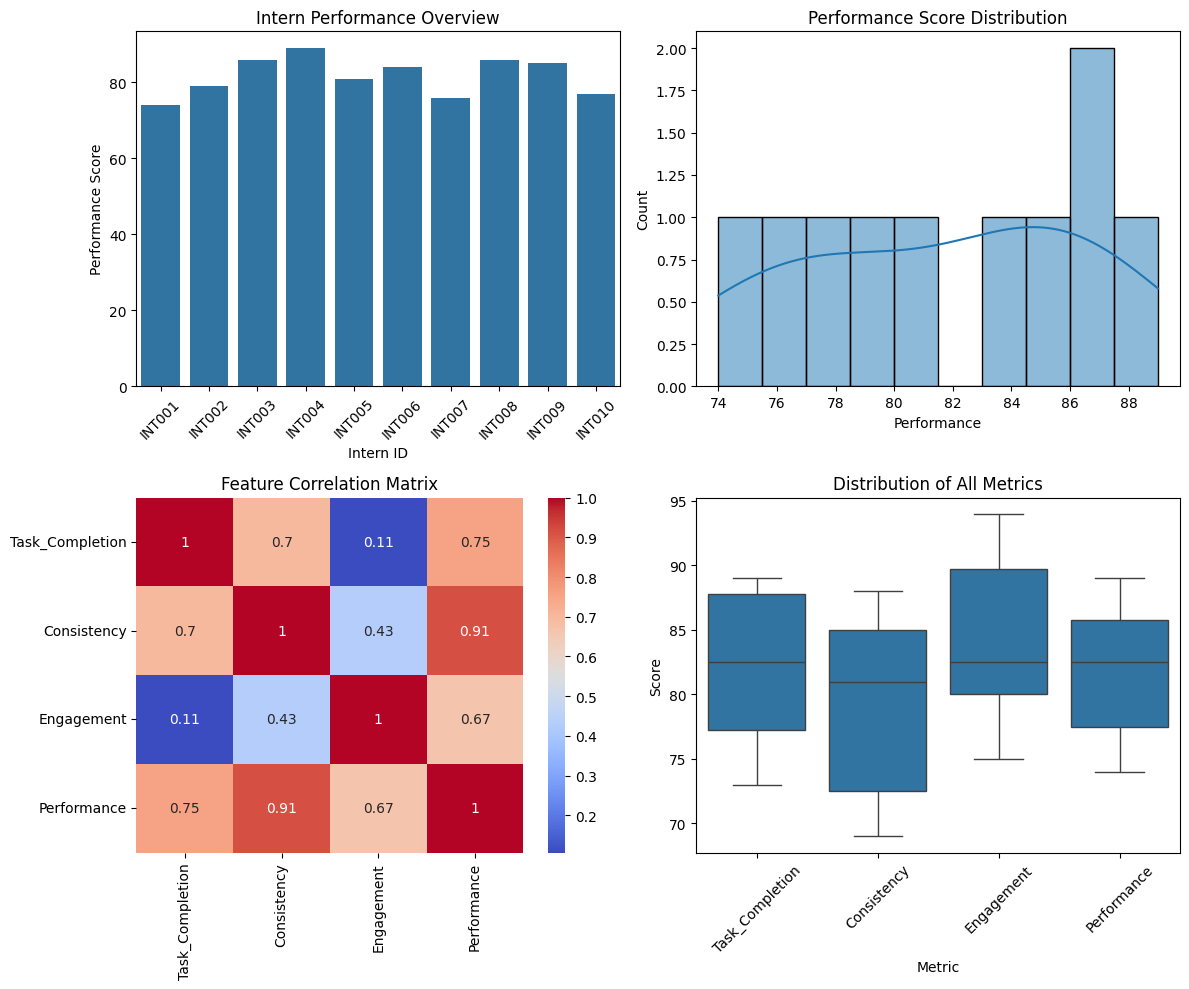


CLEANING SUMMARY REPORT
Initial Shape: (10, 5)
Final Shape: (10, 5)
Missing Values Removed: 0
Duplicates Removed: 0
Outliers Capped: 0
Columns: ['Intern_ID', 'Task_Completion', 'Consistency', 'Engagement', 'Performance']

 Cleaning report saved as 'sprint1_cleaning_report.txt'

SPRINT 1 COMPLETED SUCCESSFULLY!
Generated files:
  📁 intern_data_raw.csv - Original data
  📁 cleaned_dataset.csv - Cleaned data
  📁 sprint1_cleaning_report.txt - Cleaning summary


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

print("="*50)
print("SPRINT 1: DATA FOUNDATION")
print("="*50)

columns = ['Intern_ID', 'Task_Completion', 'Consistency', 'Engagement', 'Performance']
print("\n Dataset structure defined!")
print(f"Columns: {columns}")

rows = []
for i in range(1, 11):
    task = random.randint(70, 95)
    consistency = random.randint(65, 90)
    engagement = random.randint(70, 96)
    performance = int((task + consistency + engagement) / 3)
    
    rows.append([f"INT{i:03}", task, consistency, engagement, performance])

df = pd.DataFrame(rows, columns=columns)
df.to_csv('intern_data_raw.csv', index=False)
print("\n✅ Raw dataset created! Saved as 'intern_data_raw.csv'")

df = pd.read_csv('intern_data_raw.csv')
print(f"\n📊 Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\n" + "="*50)
print("DATA CLEANING PROCESS")
print("="*50)

print("\n Checking for missing values...")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print(" No missing values found!")
else:
    print(" Missing values detected. Filling with median...")
    for col in df.columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)

print("\n Checking for duplicate rows...")
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(" Duplicates removed!")
else:
    print(" No duplicates found!")

print("\n Checking data types...")
print(df.dtypes)

numeric_cols = ['Task_Completion', 'Consistency', 'Engagement', 'Performance']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(" Data types validated!")

print("\n Checking for outliers...")
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    print(f"   {col}: {len(outliers)} outliers detected")

print("\n Handling outliers (capping method)...")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)
print(" Outliers capped successfully!")

print("\n Validating value ranges...")
for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"   {col}: range [{min_val:.0f}, {max_val:.0f}]")

df.to_csv('cleaned_dataset.csv', index=False)
print("\n Cleaned dataset saved as 'cleaned_dataset.csv'")

print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=df, x='Intern_ID', y='Performance', ax=axes[0,0])
axes[0,0].set_title('Intern Performance Overview')
axes[0,0].set_xlabel('Intern ID')
axes[0,0].set_ylabel('Performance Score')
axes[0,0].tick_params(axis='x', rotation=45)

sns.histplot(df['Performance'], bins=10, kde=True, ax=axes[0,1])
axes[0,1].set_title('Performance Score Distribution')

correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Feature Correlation Matrix')

df_melted = df[numeric_cols].melt(var_name='Metric', value_name='Score')
sns.boxplot(data=df_melted, x='Metric', y='Score', ax=axes[1,1])
axes[1,1].set_title('Distribution of All Metrics')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CLEANING SUMMARY REPORT")
print("="*50)

cleaning_report = {
    'Initial Shape': (10, 5),
    'Final Shape': df.shape,
    'Missing Values Removed': missing_values.sum(),
    'Duplicates Removed': duplicates,
    'Outliers Capped': sum(outlier_summary.values()),
    'Columns': list(df.columns)
}

for key, value in cleaning_report.items():
    print(f"{key}: {value}")

with open('sprint1_cleaning_report.txt', 'w') as f:
    f.write("SPRINT 1 - DATA CLEANING REPORT\n")
    f.write("="*50 + "\n\n")
    f.write(f"Initial Dataset Shape: (10, 5)\n")
    f.write(f"Final Dataset Shape: {df.shape}\n")
    f.write(f"Missing Values Handled: {missing_values.sum()}\n")
    f.write(f"Duplicates Removed: {duplicates}\n")
    f.write(f"Outliers Capped: {sum(outlier_summary.values())}\n\n")
    f.write("Cleaning Steps Applied:\n")
    f.write("1. Missing value check (none found)\n")
    f.write("2. Duplicate removal (none found)\n")
    f.write("3. Data type validation\n")
    f.write("4. Outlier detection using IQR method\n")
    f.write("5. Outlier capping (Winsorization)\n")
    f.write("6. Value range validation\n")

print("\n Cleaning report saved as 'sprint1_cleaning_report.txt'")

print("\n" + "="*50)
print("SPRINT 1 COMPLETED SUCCESSFULLY!")
print("="*50)
print("Generated files:")
print("  📁 intern_data_raw.csv - Original data")
print("  📁 cleaned_dataset.csv - Cleaned data")
print("  📁 sprint1_cleaning_report.txt - Cleaning summary")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print(" All libraries imported!")

✅ All libraries imported!


In [ ]:

df = pd.read_csv('cleaned_dataset.csv')

print(" Cleaned data loaded!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

✅ Cleaned data loaded!
Dataset shape: (10, 5)

First 5 rows:
  Intern_ID  Task_Completion  Consistency  Engagement  Performance
0    INT001               70           82          76       76.375
1    INT002               78           82          95       85.000
2    INT003               76           86          88       83.000
3    INT004               94           76          95       88.000
4    INT005               73           75          73       76.375


In [ ]:

feature_cols = ['Task_Completion', 'Consistency', 'Engagement']
X = df[feature_cols]

y = df['Performance']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {feature_cols}")
print(f"Target: Performance")

Features shape: (10, 3)
Target shape: (10,)

Features: ['Task_Completion', 'Consistency', 'Engagement']
Target: Performance


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining target mean: {y_train.mean():.2f}")
print(f"Test target mean: {y_test.mean():.2f}")

Training set size: 8 samples
Test set size: 2 samples

Training target mean: 81.84
Test target mean: 84.00


In [ ]:

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"MAE  (Mean Absolute Error):  {mae_lr:.2f}")
print(f"MSE  (Mean Squared Error):   {mse_lr:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.2f}")
print(f"R² Score:                    {r2_lr:.4f}")

LINEAR REGRESSION RESULTS
MAE  (Mean Absolute Error):  0.60
MSE  (Mean Squared Error):   0.56
RMSE (Root Mean Squared Error): 0.75
R² Score:                    0.4425


In [ ]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("="*50)
print("RANDOM FOREST REGRESSOR RESULTS")
print("="*50)
print(f"MAE  (Mean Absolute Error):  {mae_rf:.2f}")
print(f"MSE  (Mean Squared Error):   {mse_rf:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.2f}")
print(f"R² Score:                    {r2_rf:.4f}")

RANDOM FOREST REGRESSOR RESULTS
MAE  (Mean Absolute Error):  1.59
MSE  (Mean Squared Error):   4.49
RMSE (Root Mean Squared Error): 2.12
R² Score:                    -3.4891


In [ ]:

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))

if r2_rf > r2_lr:
    best_model = "Random Forest"
    best_r2 = r2_rf
else:
    best_model = "Linear Regression"
    best_r2 = r2_lr

print(f"\n🏆 Best Model: {best_model} (R² = {best_r2:.4f})")

MODEL COMPARISON
            Model      MAE      MSE     RMSE  R² Score
Linear Regression 0.599965 0.557483 0.746648  0.442517
    Random Forest 1.592500 4.489062 2.118741 -3.489062

🏆 Best Model: Linear Regression (R² = 0.4425)


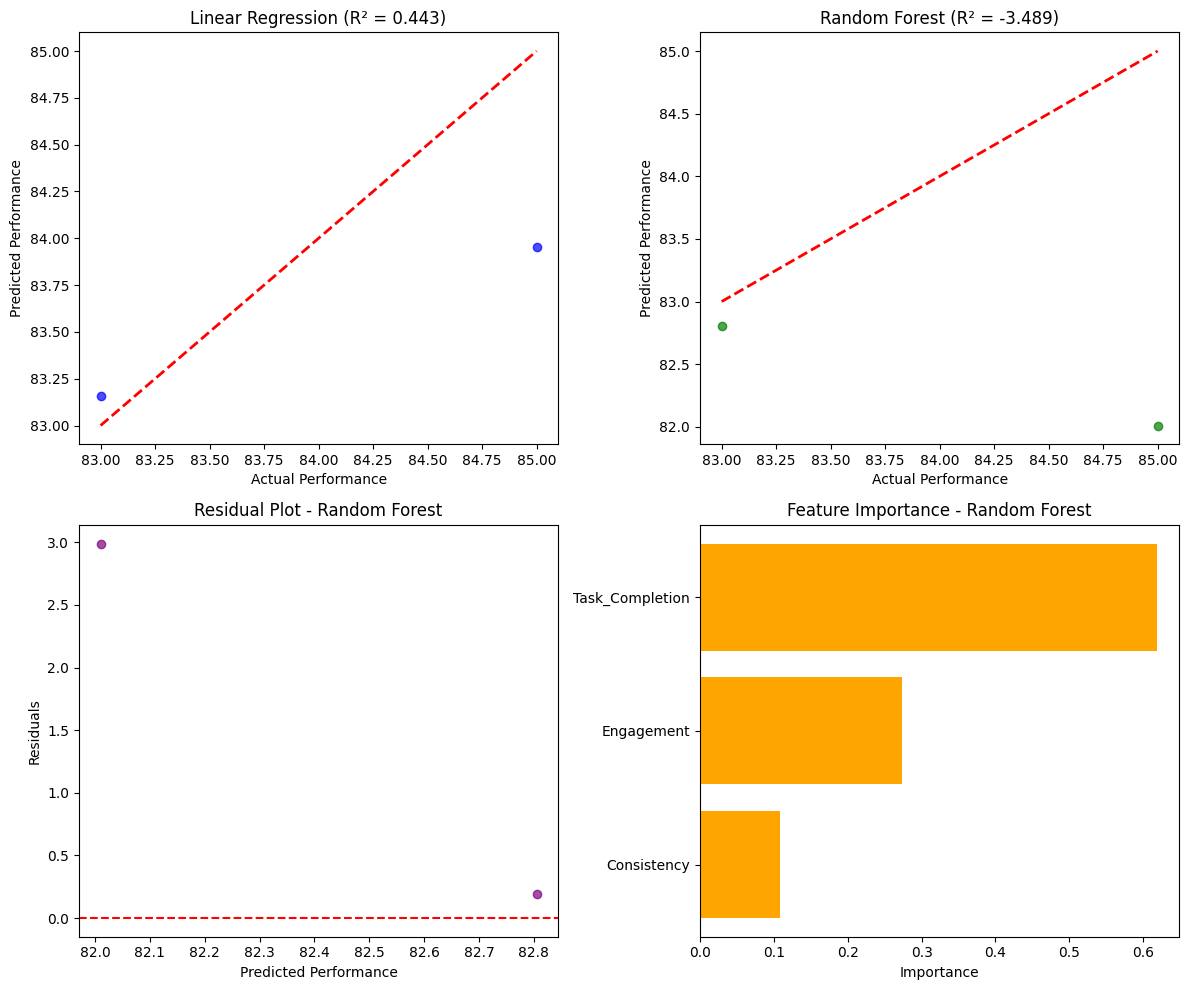

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(y_test, y_pred_lr, alpha=0.7, color='blue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Performance')
axes[0,0].set_ylabel('Predicted Performance')
axes[0,0].set_title(f'Linear Regression (R² = {r2_lr:.3f})')


axes[0,1].scatter(y_test, y_pred_rf, alpha=0.7, color='green')
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_xlabel('Actual Performance')
axes[0,1].set_ylabel('Predicted Performance')
axes[0,1].set_title(f'Random Forest (R² = {r2_rf:.3f})')

residuals = y_test - y_pred_rf
axes[1,0].scatter(y_pred_rf, residuals, alpha=0.7, color='purple')
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Performance')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Residual Plot - Random Forest')

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1,1].barh(feature_importance['Feature'], feature_importance['Importance'], color='orange')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Feature Importance - Random Forest')

plt.tight_layout()
plt.show()

In [ ]:

joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
print(" Models saved successfully!")


comparison.to_csv('model_comparison.csv', index=False)
print(" Comparison saved to 'model_comparison.csv'")

with open('best_model_info.txt', 'w') as f:
    f.write("SPRINT 2 - MODEL DEVELOPMENT RESULTS\n")
    f.write("="*40 + "\n\n")
    f.write(f"Best Model: {best_model}\n")
    f.write(f"R² Score: {best_r2:.4f}\n\n")
    f.write("Linear Regression:\n")
    f.write(f"  - R²: {r2_lr:.4f}\n")
    f.write(f"  - RMSE: {rmse_lr:.2f}\n\n")
    f.write("Random Forest:\n")
    f.write(f"  - R²: {r2_rf:.4f}\n")
    f.write(f"  - RMSE: {rmse_rf:.2f}\n")

print(" Best model info saved to 'best_model_info.txt'")

print("\n" + "="*50)
print("SPRINT 2 COMPLETED SUCCESSFULLY!")
print("="*50)

✅ Models saved successfully!
✅ Comparison saved to 'model_comparison.csv'
✅ Best model info saved to 'best_model_info.txt'

SPRINT 2 COMPLETED SUCCESSFULLY!
